=== 摇摆桥梁位移预测系统启动 ===
模型文件夹路径：./pretrained_model
=== 开始加载模型包 ===

正在加载【桥墩】的模型包：
  路径：./pretrained_model\桥墩_full_prediction_model.joblib
  ✅ 加载成功！模型类型：XGBRegressor
  ✅ 训练指标：R2=0.902

正在加载【支座】的模型包：
  路径：./pretrained_model\支座_full_prediction_model.joblib
  ✅ 加载成功！模型类型：XGBRegressor
  ✅ 训练指标：R2=0.917

正在加载【桥台】的模型包：
  路径：./pretrained_model\桥台_full_prediction_model.joblib
  ✅ 加载成功！模型类型：XGBRegressor
  ✅ 训练指标：R2=0.919

=== 开始执行三目标联合预测 ===

输入参数检查：
  直径(m)：'2'
  中跨跨径(m)：'22.86'
  墩高(m)：'6.45'
  质量系数：'1.03'
  阻尼比：'0.06'
  ED筋面积率(%)：'0.58'
  ED筋屈服强度(MPa)：'428.37'
  PT轴压比(%)：'15.87'
  SdT1(m)：'0.82'
  Sa10(g)：'0.26'
  SvT1(m/s²)：'15'
✅ 输入参数完整，共11个参数

--- 开始预测【桥墩】---
  ✅ 【桥墩】预测完成：位移=0.116330 m

--- 开始预测【支座】---
  ✅ 【支座】预测完成：位移=0.009638 m

--- 开始预测【桥台】---
  ✅ 【桥台】预测完成：位移=0.008529 m
✅ 1×3图表绘制完成：每种指标一个图，横坐标为桥墩、支座、桥台

=== 三目标联合预测全部完成 ===


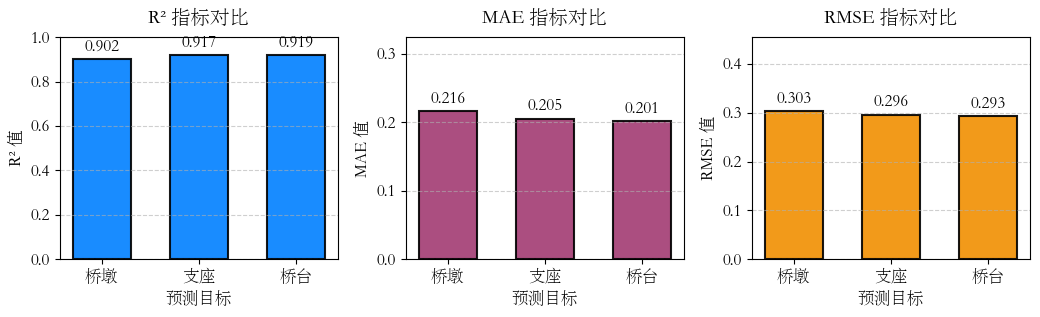

In [1]:
import tkinter as tk
from tkinter import ttk, filedialog, messagebox, scrolledtext
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# --------------------------
# 核心配置（仅修改指定参数名称）
# --------------------------
MODEL_FOLDER = "./pretrained_model"
INPUT_PARAMS = [
    ("直径(m)", "m"),
    ("中跨跨径(m)", "m"),
    ("墩高(m)", "m"),
    ("质量系数", ""),
    ("阻尼比", ""),  # 修改：阻尼比（%）→ 阻尼比
    ("ED筋面积率(%)", "%"),
    ("ED筋屈服强度(MPa)", "MPa"),
    ("PT轴压比(%)", ""),  # 修改：PT轴压比 → PT轴压比(%)
    ("SdT1(m)", "m"),  # 修改：SdT1(m/s²) → SdT1(m)
    ("Sa10(g)", "g"),  # 修改：Sa10(m/s²) → Sa10(g)
    ("SvT1(m/s²)", "m/s²")
]
# 预先填写的参数值（同步修改参数名键）
INITIAL_PARAM_VALUES = {
    "直径(m)": "2",
    "中跨跨径(m)": "22.86",
    "墩高(m)": "6.45",
    "质量系数": "1.03",
    "阻尼比": "0.06",  # 同步修改
    "ED筋面积率(%)": "0.58",
    "ED筋屈服强度(MPa)": "428.37",
    "PT轴压比(%)": "15.87",  # 同步修改
    "SdT1(m)": "0.82",  # 同步修改
    "Sa10(g)": "0.26",  # 同步修改
    "SvT1(m/s²)": "15"
}
OUTPUT_LABELS = ["桥墩", "支座", "桥台"]
MODEL_FILENAME_TPL = "{label}_full_prediction_model.joblib"
METRIC_NAMES = ["R²", "MAE", "RMSE"]

# 按要求定义三行参数顺序（同步修改参数名引用）
ROW1_PARAMS = ["直径(m)", "中跨跨径(m)", "墩高(m)", "质量系数"]  # 第一行
ROW2_PARAMS = ["阻尼比", "ED筋面积率(%)", "ED筋屈服强度(MPa)", "PT轴压比(%)"]  # 第二行（同步修改）
ROW3_PARAMS = ["SdT1(m)", "Sa10(g)", "SvT1(m/s²)"]  # 第三行（同步修改）

# --------------------------
# GUI主类（优化后）
# --------------------------
class BridgePredictionGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("摇摆桥梁位移预测系统")
        # 核心修改：将界面宽度从1200减小到1100，高度保持900不变
        self.root.geometry("1100x900")
        self.root.resizable(True, True)
        
        self.model_packages = {}
        self.input_vars = {}
        self.pred_results = {}
        self.first_entry = None  # 存储第一个输入框，用于后续设置焦点
        
        self._init_layout()
        self._auto_load_model_packages()
        # 界面初始化完成后，强制设置第一个输入框焦点
        self.root.after(100, self.set_first_entry_focus)

    def set_first_entry_focus(self):
        """强制让第一个输入框获取焦点"""
        if self.first_entry:
            self.first_entry.focus_force()

    def _init_layout(self):
        # 创建主容器
        main_frame = ttk.Frame(self.root, padding=10)
        main_frame.pack(fill=tk.BOTH, expand=True)
        
        # 移除模型状态区域：删除 _create_status_frame 调用
        
        # 参数输入区域（顶部）
        self._create_input_frame(main_frame)
        
        # 预测按钮区域（居中）
        self._create_button_frame(main_frame)
        
        # 预测结果区域（按钮下方）
        self._create_result_frame(main_frame)
        
        # 性能指标图表区域（最底部）
        self._create_chart_frame(main_frame)

    def _create_input_frame(self, parent):
        """输入框预填参数，按要求排列3行（4+4+3）"""
        frame = ttk.LabelFrame(parent, text="输入参数配置", padding=(10, 10))
        frame.pack(fill=tk.X, pady=(0, 10))
        
        ttk.Label(
            frame, 
            text="预测说明：输入参数后，点击预测按钮将输出桥墩、支座、桥台三个目标的位移预测值及性能指标图表", 
            font=('Arial', 9, 'italic'),
            foreground="#666"
        ).pack(anchor=tk.W, pady=(0, 10))
        
        # 参数网格布局
        params_frame = ttk.Frame(frame)
        params_frame.pack(fill=tk.X)
        
        # 第一行：4个参数（直径(m)、中跨跨径(m)、墩高(m)、质量系数）
        row1 = ttk.Frame(params_frame)
        row1.pack(fill=tk.X, pady=(0, 15))
        # 配置列宽，使每个参数区域均匀分布
        for col in range(4):
            row1.columnconfigure(col, weight=1)
        for col, param_name in enumerate(ROW1_PARAMS):
            # 找到参数对应的信息（仅用参数名，忽略单位）
            param_info = next((p for p in INPUT_PARAMS if p[0] == param_name), None)
            if param_info:
                self._create_param_widget(row1, param_info, col, 0)
        
        # 第二行：4个参数（阻尼比、ED筋面积率(%)、ED筋屈服强度(MPa)、PT轴压比(%)）
        row2 = ttk.Frame(params_frame)
        row2.pack(fill=tk.X, pady=(0, 15))
        for col in range(4):
            row2.columnconfigure(col, weight=1)
        for col, param_name in enumerate(ROW2_PARAMS):
            param_info = next((p for p in INPUT_PARAMS if p[0] == param_name), None)
            if param_info:
                self._create_param_widget(row2, param_info, col, 1)
        
        # 第三行：3个参数（SdT1(m)、Sa10(g)、SvT1(m/s²)）
        row3 = ttk.Frame(params_frame)
        row3.pack(fill=tk.X)
        for col in range(3):
            row3.columnconfigure(col, weight=1)
        for col, param_name in enumerate(ROW3_PARAMS):
            param_info = next((p for p in INPUT_PARAMS if p[0] == param_name), None)
            if param_info:
                self._create_param_widget(row3, param_info, col, 2)

    def _create_param_widget(self, parent, param_info, col, row_idx):
        """创建单个参数的标签（无单位）、输入框（下），垂直排列"""
        param, _ = param_info  # 忽略单位（参数名已包含单位信息）
        # 每个参数的容器，垂直布局
        frame = ttk.Frame(parent)
        # 核心修改1：将参数间水平间距从padx=1改为padx=0，缩小至约两个字距离
        frame.grid(row=0, column=col, padx=0, pady=5, sticky=tk.N)
        
        # 水平框架：仅包含参数标签（删除单位标签）
        label_frame = ttk.Frame(frame)
        label_frame.pack(side=tk.TOP, pady=(0, 5))
        
        # 参数标签：字体保持12号，添加bold属性实现加粗
        ttk.Label(
            label_frame, 
            text=param, 
            anchor='center', 
            width=18,
            font=('STSong', 12, 'bold')  # 核心修改2：添加'bold'实现字体加粗
        ).pack(side=tk.LEFT)
        
        # 输入框（中间，居中，位置和样式完全不变）
        var = tk.StringVar()
        var.set(INITIAL_PARAM_VALUES[param])
        self.input_vars[param] = var
        
        validate_cmd = self.root.register(lambda x: x == "" or x.replace('.', '', 1).isdigit())
        entry = ttk.Entry(
            frame, 
            textvariable=var, 
            width=10, 
            validate='key', 
            validatecommand=(validate_cmd, '%P'),
            justify=tk.CENTER  # 输入内容居中
        )
        entry.pack(side=tk.TOP, padx=(5, 5))
        
        # 记录第一个输入框（第一行第一列）
        if row_idx == 0 and col == 0:
            self.first_entry = entry

    def _create_button_frame(self, parent):
        """创建居中的预测按钮"""
        frame = ttk.Frame(parent)
        frame.pack(fill=tk.X, pady=(0, 10))
        
        # 按钮居中
        btn_frame = ttk.Frame(frame)
        btn_frame.pack(anchor=tk.CENTER)
        
        ttk.Button(
            btn_frame, 
            text="预测响应", 
            command=self._run_prediction, 
            style='Accent.TButton',
            width=15
        ).pack(pady=10)

    def _create_result_frame(self, parent):
        """创建预测结果显示区域"""
        frame = ttk.LabelFrame(parent, text="预测结果", padding=(10, 10))
        frame.pack(fill=tk.X, pady=(0, 10))
        
        # 预测结果栏高度缩小（从6改为3），仅足够显示标题+一行预测值
        self.result_text = scrolledtext.ScrolledText(
            frame, 
            width=80, 
            height=3,  # 仅保留3行高度，刚好显示标题和预测值
            font=('STSong', 16)
        )
        self.result_text.pack(fill=tk.X, padx=5, pady=3)
        self.result_text.insert(
            tk.END, 
            "请加载模型并输入参数后点击预测按钮...\n预测完成后将显示桥墩、支座、桥台三个目标的位移预测值。"
        )
        self.result_text.config(state='disabled')

    def _create_chart_frame(self, parent):
        """创建性能指标图表区域（最底部）"""
        frame = ttk.LabelFrame(parent, text="性能指标图表", padding=(10, 10))
        frame.pack(fill=tk.BOTH, expand=True)
        
        ttk.Label(
            frame, 
            text="1×3性能指标图表（左：R²，中：MAE，右：RMSE；横坐标均为桥墩、支座、桥台）：", 
            font=('Arial', 10, 'bold')
        ).pack(anchor=tk.W, pady=(0, 10))
        
        # 创建图表：图表高度增大（figsize从(14,4)改为(14,6)）
        self.fig, self.axes = plt.subplots(
            1, 3, figsize=(14, 6), dpi=100, squeeze=False
        )
        self.fig.patch.set_facecolor('white')
        plt.rcParams['font.family'] = ['STSong', 'Times New Roman']
        plt.rcParams['axes.unicode_minus'] = False
        plt.rcParams['font.size'] = 12
        plt.rcParams['axes.titlesize'] = 14
        plt.rcParams['xtick.labelsize'] = 12
        plt.rcParams['ytick.labelsize'] = 12
        
        plt.subplots_adjust(left=0.08, right=0.92, top=0.85, bottom=0.2, hspace=0.3, wspace=0.3)
        
        self.canvas = FigureCanvasTkAgg(self.fig, master=frame)
        self.canvas.draw()
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

    def _auto_load_model_packages(self):
        print("=== 开始加载模型包 ===")
        if not os.path.exists(MODEL_FOLDER):
            messagebox.showwarning("路径错误", "模型文件夹不存在，请检查路径")
            return
        
        loaded_count = 0
        for label in OUTPUT_LABELS:
            model_path = os.path.join(MODEL_FOLDER, MODEL_FILENAME_TPL.format(label=label))
            print(f"\n正在加载【{label}】的模型包：")
            print(f"  路径：{model_path}")
            
            try:
                model_package = joblib.load(model_path)
                required_keys = ['model', 'scaler_X', 'scaler_y', 'train_metrics']
                missing_keys = [k for k in required_keys if k not in model_package]
                if missing_keys:
                    raise ValueError(f"模型包缺少必要组件：{missing_keys}")
                
                self.model_packages[label] = model_package
                loaded_count += 1
                model_type = type(model_package['model']).__name__
                print(f"  ✅ 加载成功！模型类型：{model_type}")
                print(f"  ✅ 训练指标：R2={model_package['train_metrics']['R2']:.3f}")

            except Exception as e:
                error_msg = f"  ❌ 加载失败：{str(e)}"
                print(error_msg)
                messagebox.showwarning("模型加载警告", f"【{label}】加载失败：{str(e)}\n请确保三个模型包都存在且完整")
        
        if loaded_count == 3:
            messagebox.showinfo(
                "加载成功", 
                f"已自动加载所有3个预训练模型！\n将同时输出：{', '.join(OUTPUT_LABELS)}的预测结果"
            )
        else:
            messagebox.showwarning("模型加载不完整", f"未加载完整模型（仅加载{loaded_count}/3个）\n请检查缺失模型的文件是否存在")

    def _run_prediction(self):
        print("\n" + "="*60)
        print("=== 开始执行三目标联合预测 ===")
        try:
            if len(self.model_packages) != 3:
                raise ValueError("需加载桥墩、支座、桥台三个模型包才能执行预测")
            
            input_data = []
            missing_params = []
            print("\n输入参数检查：")
            for param, var in self.input_vars.items():
                value = var.get().strip()
                print(f"  {param}：'{value}'")
                if not value:
                    missing_params.append(param)
                    continue
                input_data.append(float(value))
            
            if missing_params:
                raise ValueError(f"以下参数未输入：{', '.join(missing_params)}")
            print(f"✅ 输入参数完整，共{len(input_data)}个参数")
            
            input_array = np.array(input_data).reshape(1, -1)
            self.pred_results.clear()
            for label in OUTPUT_LABELS:
                print(f"\n--- 开始预测【{label}】---")
                pkg = self.model_packages[label]
                model = pkg['model']
                scaler_X = pkg['scaler_X']
                scaler_y = pkg['scaler_y']
                train_metrics = pkg['train_metrics']
                
                input_scaled = scaler_X.transform(input_array)
                y_pred_scaled = model.predict(input_scaled)
                y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()[0]
                
                self.pred_results[label] = {
                    'pred_value': y_pred,
                    'metrics': train_metrics
                }
                print(f"  ✅ 【{label}】预测完成：位移={y_pred:.6f} m")
            
            self._update_result_text()
            self._plot_1x3_metrics()
            print("\n=== 三目标联合预测全部完成 ===")

        except Exception as e:
            error_msg = f"预测失败：{str(e)}"
            print(f"❌ {error_msg}")
            messagebox.showerror("预测错误", error_msg)
            self._update_result_text(error_msg)

    def _update_result_text(self, error_msg=""):
        self.result_text.config(state='normal')
        self.result_text.delete(1.0, tk.END)
        
        if error_msg:
            self.result_text.insert(tk.END, f"=== 预测失败 ===\n{error_msg}\n\n")
            self.result_text.insert(tk.END, "请检查以下问题：\n1. 三个模型包是否都加载成功\n2. 所有参数是否都已输入\n3. 输入参数是否为有效数字\n")
        else:
            self.result_text.insert(tk.END, f"=== 三目标位移预测结果 ===\n\n")
            # 三个预测值保持一行显示（不变）
            result_line = ""
            for label in OUTPUT_LABELS:
                res = self.pred_results[label]
                pred_value = res['pred_value']
                result_line += f"📊 【{label}】预测位移值：{pred_value:.6f} m\t\t"
            self.result_text.insert(tk.END, result_line)
        
        self.result_text.config(state='disabled')

    def _plot_1x3_metrics(self):
        """绘制1×3图表，增大所有字体，缩小图表尺寸"""
        try:
            color_map = {
                "R²": "#0080FF",    # 蓝色
                "MAE": '#A23B72',   # 紫色
                "RMSE": '#F18F01'   # 橙色
            }
            
            # 清空所有子图
            for row in range(1):
                for col in range(3):
                    ax = self.axes[row, col]
                    ax.clear()
                    ax.set_facecolor('#ffffff')
            
            # 收集每个指标在三个目标上的数据
            metric_data = {}
            for metric in METRIC_NAMES:
                data = []
                for label in OUTPUT_LABELS:
                    metrics = self.pred_results[label]['metrics']
                    if metric == "R²":
                        value = metrics['R2']
                    else:
                        value = metrics[metric]
                    data.append(round(value, 3))  # 保留三位小数
                metric_data[metric] = data
            
            # 绘制每个指标的图表（1行3列）
            for col_idx, metric in enumerate(METRIC_NAMES):
                ax = self.axes[0, col_idx]
                x_pos = np.arange(len(OUTPUT_LABELS))  # 横坐标位置
                values = metric_data[metric]
            
                # 绘制柱状图
                bars = ax.bar(
                    x_pos,
                    values,
                    width=0.6,
                    color=color_map[metric],
                    alpha=0.9,
                    edgecolor='black',
                    linewidth=1.5
                )
            
                # 设置图表标题和标签
                ax.set_title(f'{metric} 指标对比', pad=10)
                ax.set_xlabel('预测目标')
                ax.set_ylabel(f'{metric} 值')
            
                # 设置横坐标刻度和标签
                ax.set_xticks(x_pos)
                ax.set_xticklabels(OUTPUT_LABELS)
            
                # 优化y轴范围
                if metric == "R²":
                    ax.set_ylim(0, 1.0)  # R²最大值固定为1
                else:
                    ax.set_ylim(0, max(values) * 1.5 if max(values) > 0 else 0.1)
            
                # 添加网格线
                ax.grid(axis='y', linestyle='--', alpha=0.6)
            
                # 柱子顶部数值
                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    ax.text(
                        bar.get_x() + bar.get_width()/2.,
                        height + (ax.get_ylim()[1] * 0.02),
                        f'{value:.3f}',
                        ha='center',
                        va='bottom',
                        fontsize=12,
                        fontweight='bold'
                    )
            
            plt.tight_layout()
            self.canvas.draw()
            print("✅ 1×3图表绘制完成：每种指标一个图，横坐标为桥墩、支座、桥台")
        except Exception as e:
            error_msg = f"图表绘制失败：{str(e)}"
            print(f"⚠️ {error_msg}")
            messagebox.showwarning("图表错误", error_msg)

# --------------------------
# 启动GUI
# --------------------------
if __name__ == "__main__":
    root = tk.Tk()
    root.style = ttk.Style(root)
    root.style.configure(
        'Accent.TButton', 
        background='#2E86AB', 
        foreground='black',
        font=('Arial', 10, 'bold')
    )
    print("=== 摇摆桥梁位移预测系统启动 ===")
    print(f"模型文件夹路径：{MODEL_FOLDER}")
    app = BridgePredictionGUI(root)
    root.mainloop()